# Lire le dataset issu de l'étape feature engineering 

1. Chargement

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/step3_feature_engineering.csv')


print("Shape initial :", df.shape)
df.head()


Shape initial : (4372, 67)


,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,...,EngagementScore,CustomerScore,CustomerScoreNormalized,MonetaryPerDay_log,AvgBasketValue_log,ReturnImpact_log,RegMonth_sin,RegMonth_cos,RegWeekday_sin,RegWeekday_cos
0,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,0,...,1752,2189.852,30.842986,2.915293,4.996580,5.542287,-0.500000,-8.660254e-01,-0.974928,-0.222521
1,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,0,...,1479,1245.240,3.641053,4.546545,5.094105,5.934981,0.866025,-5.000000e-01,-0.974928,-0.222521
2,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,0,...,5142,2882.736,7.791178,7.494338,5.938277,4.749611,-1.000000,-1.836970e-16,-0.974928,-0.222521
3,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,...,468,400.500,1.440647,2.377300,5.069166,0.000000,0.500000,8.660254e-01,0.433884,-0.900969
4,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,0,...,65,322.440,7.498605,1.071149,4.518834,5.763779,-0.866025,5.000000e-01,0.000000,1.000000


2. Vérification

In [2]:
print("Valeurs manquantes :", df.isnull().sum().sum())

Valeurs manquantes : 0


3. Séparer X / y

In [3]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# X → données d’entrée
# y → ce que tu veux prédire

4. Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

5. Encoding

In [5]:
# cat_cols = X_train.select_dtypes(include=['object']).columns

# X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
# Transformer texte → nombres
# X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# aligner colonnes
# X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
# 'left' on garde les colonnes de X_train
# On force les deux datasets à avoir les mêmes colonnes
# fill_value=0 si une colonne n'existe pas dans X_test → mettre 0

# Supprimer toutes les colonnes qui contiennent 'ChurnRiskCategory'
leak_cols = ['ChurnRiskCategory', 'CustomerType', 'RFMSegment', 'LoyaltyLevel']
X_train = X_train.drop(columns=[col for col in leak_cols if col in X_train.columns])
X_test  = X_test.drop(columns=[col for col in leak_cols if col in X_test.columns])
# --- Détection automatique des colonnes suspectes ---

# leak_cols = [col for col in X_train.columns if "churn" in col.lower()]
# if leak_cols:
#     print("⚠️ Colonnes fuite détectées :", leak_cols)
#     X_train = X_train.drop(columns=leak_cols)
#     X_test  = X_test.drop(columns=[col for col in leak_cols if col in X_test.columns])
# else:
#     print("✅ pas de fuite détectée !")


# Puis faire le get_dummies normalement
cat_cols = X_train.select_dtypes(include=['object']).columns
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)



6. Gestion des valeurs infinies / NaN

In [6]:
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train.fillna(X_train.median(numeric_only=True), inplace=True)
X_test.fillna(X_train.median(numeric_only=True), inplace=True)

7. StandardScaler

In [7]:
# Mettre toutes les variables numériques à la même échelle
scaler = StandardScaler() #crées l’outil de normalisation

X_train_before = X_train.copy()

num_cols = X_train.select_dtypes(include=['int64','float64']).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols]) #le scaler apprend sur TRAIN
X_test[num_cols] = scaler.transform(X_test[num_cols]) # le scaler applique la même transformation sur TEST

# Visualiser AVANT / APRÈS scaling

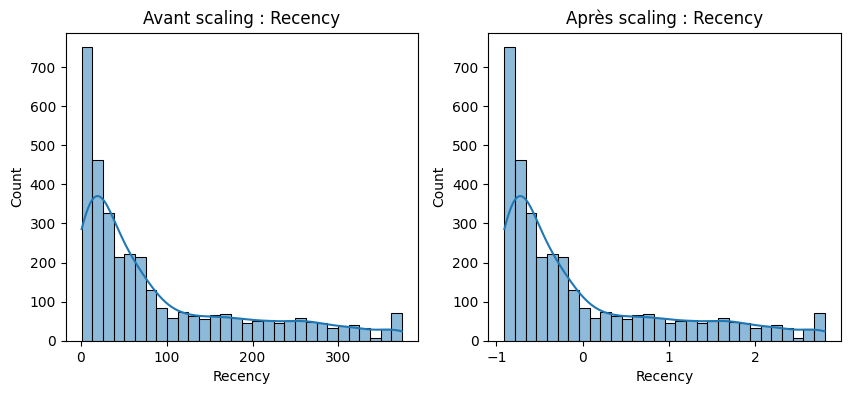

In [8]:


col = num_cols[0]  # une feature exemple

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(X_train_before[col], bins=30, kde=True)
plt.title(f"Avant scaling : {col}")

plt.subplot(1,2,2)
sns.histplot(X_train[col], bins=30, kde=True)
plt.title(f"Après scaling : {col}")

plt.show()


8. Analyse déséquilibre

In [9]:
print(y.value_counts())
# 0	Client fidèle	2918
# 1	Client parti	1454

Churn
0    2918
1    1454
Name: count, dtype: int64


9. SMOTE

In [10]:
# pour équilibrer les classes 50/50
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(y_train_resampled.value_counts())

Churn
0    2334
1    2334
Name: count, dtype: int64


# Visualiser AVANT / APRÈS SMOTE

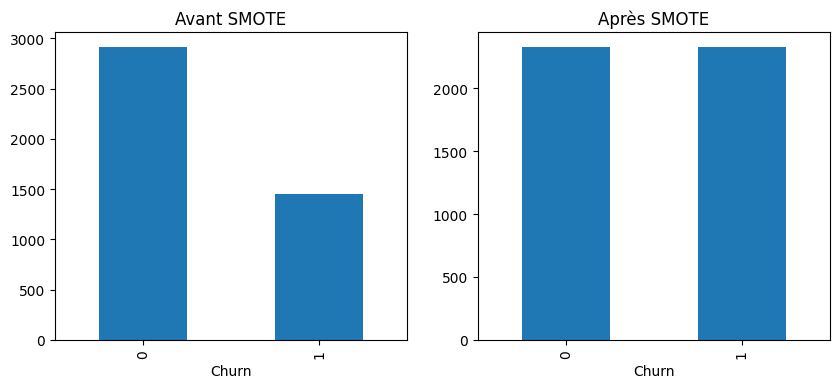

In [11]:
fig, axes = plt.subplots(1,2, figsize=(10,4))

y.value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Avant SMOTE")

y_train_resampled.value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title("Après SMOTE")

plt.show()


10. PCA

In [12]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_resampled)
X_test_pca = pca.transform(X_test)

print("Shape PCA :", X_train_pca.shape)

Shape PCA : (4668, 39)


# Visualiser PCA

1. Variance expliquée

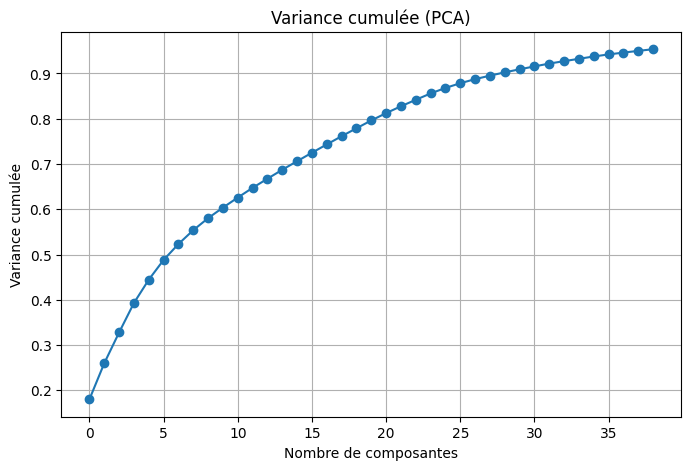

In [13]:

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.title("Variance cumulée (PCA)")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée")
plt.grid()
plt.show()


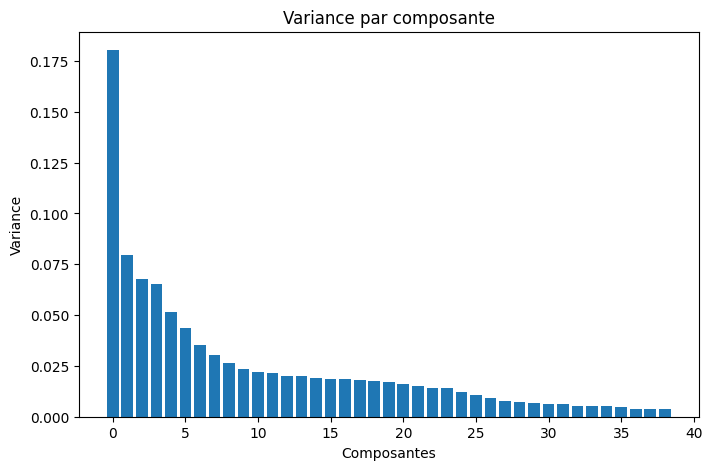

In [14]:
plt.figure(figsize=(8,5))
plt.bar(range(len(explained_variance)), explained_variance)
plt.title("Variance par composante")
plt.xlabel("Composantes")
plt.ylabel("Variance")
plt.show()


In [15]:
print(pca.components_)
components = pd.DataFrame(
    pca.components_, 
    columns=X_train.columns
)

# trier les poids de PC1
pc1 = components.iloc[0].abs().sort_values(ascending=False)

print(pc1.head(10))


[[-1.85464571e-01  2.42129379e-01  2.09094703e-01 ... -1.82610811e-04
  -8.64377570e-03 -1.41188010e-04]
 [-1.76492811e-01 -1.06437417e-01 -1.16208755e-01 ... -3.39455869e-05
  -5.84262168e-03  1.08695342e-03]
 [-9.74497623e-02 -5.59491094e-02 -3.64199879e-02 ...  2.15756520e-05
  -3.81281974e-03  9.06178345e-04]
 ...
 [ 5.34909051e-02  5.08358239e-02 -1.09990980e-02 ...  4.54242802e-03
  -2.71993050e-01  4.29825840e-04]
 [ 3.01506682e-02  1.66206693e-01 -2.09629598e-02 ...  7.70524969e-04
  -1.90016984e-01  5.14022106e-03]
 [-9.08898021e-02 -1.11764481e-03 -1.64126976e-02 ...  1.15066789e-03
  -9.80010995e-02 -5.56844936e-03]]
MonetaryPerDay_log    0.260493
MonetaryTotal_log     0.257209
Frequency             0.242129
UniqueInvoices        0.242129
UniqueDescriptions    0.232869
UniqueProducts        0.232251
EngagementScore       0.225412
TotalQuantity         0.222446
CustomerTenureDays    0.211691
MonetaryTotal         0.209095
Name: 0, dtype: float64


2. Projection 2D

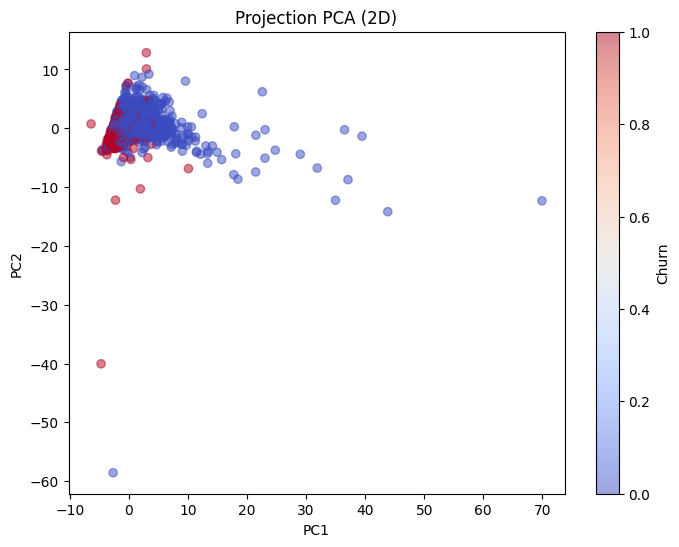

In [16]:

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_train, cmap='coolwarm', alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection PCA (2D)")
plt.colorbar(label="Churn")
plt.show()


# Vérification finale dataset

In [17]:
print("Shape final :", X_train_pca.shape)
print("Valeurs manquantes :", X_train.isnull().sum().sum())


Shape final : (4668, 39)
Valeurs manquantes : 0


11. Sauvegarde

In [18]:
# version classique
X_train.to_csv('../data/train_test/X_train.csv', index=False)
X_test.to_csv('../data/train_test/X_test.csv', index=False)

# version SMOTE
pd.DataFrame(X_train_resampled).to_csv('../data/train_test/X_train_smote.csv', index=False)
pd.DataFrame(y_train_resampled).to_csv('../data/train_test/y_train_smote.csv', index=False)

# version PCA
pd.DataFrame(X_train_pca).to_csv('../data/train_test/X_train_pca.csv', index=False)
pd.DataFrame(X_test_pca).to_csv('../data/train_test/X_test_pca.csv', index=False)

# labels
y_train.to_csv('../data/train_test/y_train.csv', index=False)
y_test.to_csv('../data/train_test/y_test.csv', index=False)


print("Données sauvegardées !")


Données sauvegardées !
